In [220]:
import networkx
import graphviz

In [267]:
phylonet = graphviz.Digraph('N', filename='network', engine='neato',
                            graph_attr={'splines': 'true', 'overlap': 'false'})
n = 3
m = 3
virus_edges = [('x1', '1'), ('x1', '2'), ('x2', 'x1'), ('x2', '3')]
host_edges = [('y1', '1'), ('y1', '2'), ('y2', 'y1'), ('y2', '3')]
host_nodes = ['y1', 'y2']
virus_nodes = ['x1', 'x2']


coord = 0
for i in range(1, n+1):
    for j in range(1, m+1):
        label = f'<a<SUB>{i}{j}</SUB>>'               # a_{11}, a_{12}, …
        phylonet.node(f'a{i}{j}', label=label,
                      pos=f'{coord},0!')
        coord += 1


ycoord = 2
for node_idx, node in enumerate(host_nodes):
    k = node[1:]                               # 'y1' → '1'
    xcoord = node_idx + 0.5
    for i in range(1, n+1):
        label = f'<({i},y<SUB>{k}</SUB>)>'      # <(1,y₁)>
        phylonet.node(f'({i},{node})', label=label,
                      pos=f'{xcoord},{ycoord}!')
        xcoord += 2.5
    ycoord += 1.7



ycoord = 1
for node_idx, node in enumerate(virus_nodes):
    k = node[1:]                               # 'x1' → '1'
    xcoord = 2*node_idx + 1 + 0.5 - 0.5*node_idx
    for j in range(1, m+1):
        label = f'<(x<SUB>{k}</SUB>,{j})>'      # <(x₁,1)>
        phylonet.node(f'({node},{j})', label=label,
                      pos=f'{xcoord},{ycoord}!')
        xcoord += 1.5
    ycoord += 2


for i in range(1, n+1):
    for src, tgt in host_edges:
        src_node = f'({i},{src})'                 # e.g. (1,y1)
        if len(tgt) == 1:                         # leaf a{i}{tgt}
            tgt_node = f'a{i}{tgt}'
            # weight: w_h(a_{ij})
            weight = f'<w<SUB>h</SUB>(a<SUB>{i}{tgt}</SUB>)>'
        else:                                     # internal y-node
            tgt_node = f'({i},{tgt})'
            # weight: w_h(y_k)   (k is the number after "y")
            k = tgt[1:]
            weight = f'<w<SUB>h</SUB>(y<SUB>{k}</SUB>)>'

        phylonet.edge(src_node, tgt_node,
                      color='red',
                      label=weight,
                      fontname='Times',
                      fontsize='10')
        

# ──────────────────────────────────────────────────────────────
# Virus edges → green + w_v(·)
# ──────────────────────────────────────────────────────────────
for j in range(1, m+1):
    for src, tgt in virus_edges:
        src_node = f'({src},{j})'                 # e.g. (x1,1)
        if len(tgt) == 1:                         # leaf a{tgt}{j}
            tgt_node = f'a{tgt}{j}'
            # weight: w_v(a_{kj})
            weight = f'<w<SUB>v</SUB>(a<SUB>{tgt}{j}</SUB>)>'
        else:                                     # internal x-node
            tgt_node = f'({tgt},{j})'
            # weight: w_v(x_k)   (k is the number after "x")
            k = tgt[1:]
            weight = f'<w<SUB>v</SUB>(x<SUB>{k}</SUB>)>'

        phylonet.edge(src_node, tgt_node,
                      color='green',
                      label=weight,
                      fontname='Times',
                      fontsize='10')

phylonet.node('R', label='<r(N)>', pos='4,5!')   # High up, centered
for i in range(1, n+1):
    src = f'({i},y2)'

    phylonet.edge('R', src,
                  color='blue',
                  fontname='Times',
                  fontsize='8',
                  labelangle='0')

for j in range(1, m+1):
    src = f'(x2,{j})'
    
    phylonet.edge('R', src,
                  color='blue',
                  fontname='Times',
                  fontsize='8',
                  labelangle='0')

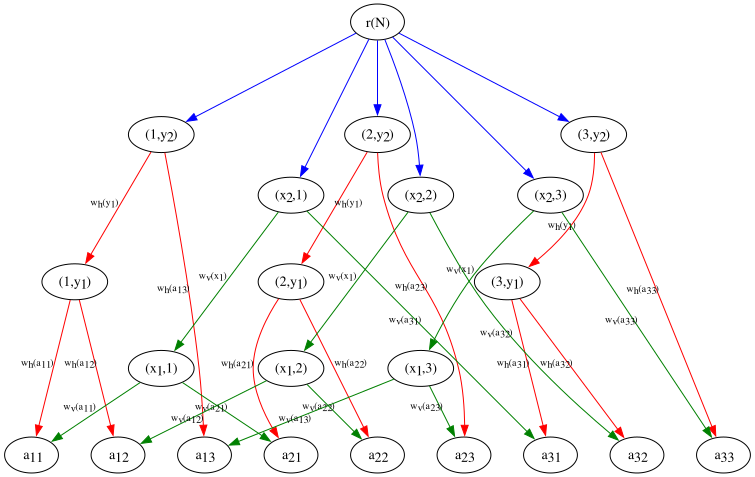

In [268]:
phylonet

In [255]:
phylonet.render('phylonet_network', format='svg', cleanup=True)

'phylonet_network.svg'